In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(".")


.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load World Happiness Report data (2015-2024)
happiness = pd.read_csv('world_happiness_combined.csv', sep=';', decimal=',')
print(happiness.shape)
happiness.head()

(1502, 11)


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,7.587,8.26132,0.96240,73,0.99379,0.37289,0.23941,2015
1,2,Iceland,Western Europe,7.561,7.70416,1.00000,73,0.93884,0.54819,0.74371,2015
2,3,Denmark,Western Europe,7.527,7.84114,0.97030,70,0.96962,0.42894,0.12382,2015
3,4,Norway,Western Europe,7.522,8.63100,0.94917,71,1.00000,0.43598,0.33860,2015
4,5,Canada,North America and ANZ,7.427,7.84595,0.94322,71,0.94511,0.57560,0.40285,2015


In [3]:
# Check working directory and list available files
import os
print(os.getcwd())
print(os.listdir())

/Users/yarenerdogdu/anaconda_projects/6b8b73ca-f325-4681-b2cb-bab59c3681b4
['learning_curves_regularized.png', 'world_happiness_combined.csv', 'API_NY.GDP.PCAP.KD.ZG_DS2_en_csv_v2_376.csv', 'learning_curves.png', 'dsa proje.ipynb', 'gdp_vs_happiness.png', 'API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv', 'happiness_economic_clean.csv', 'feature_importance.png', 'correlation_heatmap.png', 'dsa.ipynb', 'region_happiness.png', 'API_NY.GDP.DEFL.KD.ZG_DS2_en_csv_v2_242.csv', '.ipynb_checkpoints', 'milestone2.ipynb', 'pred_vs_actual.png']


In [7]:
import os
print(os.getcwd())

/Users/yarenerdogdu/anaconda_projects/6b8b73ca-f325-4681-b2cb-bab59c3681b4


In [8]:

happiness = pd.read_csv('world_happiness_combined.csv', sep=';', decimal=',')
print(happiness.shape)
happiness.head()

(1502, 11)


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,7.587,8.26132,0.96240,73,0.99379,0.37289,0.23941,2015
1,2,Iceland,Western Europe,7.561,7.70416,1.00000,73,0.93884,0.54819,0.74371,2015
2,3,Denmark,Western Europe,7.527,7.84114,0.97030,70,0.96962,0.42894,0.12382,2015
3,4,Norway,Western Europe,7.522,8.63100,0.94917,71,1.00000,0.43598,0.33860,2015
4,5,Canada,North America and ANZ,7.427,7.84595,0.94322,71,0.94511,0.57560,0.40285,2015


In [9]:
import os

files = os.listdir('.')
for f in files:
    print(f)

learning_curves_regularized.png
world_happiness_combined.csv
API_NY.GDP.PCAP.KD.ZG_DS2_en_csv_v2_376.csv
learning_curves.png
dsa proje.ipynb
gdp_vs_happiness.png
API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv
happiness_economic_clean.csv
feature_importance.png
correlation_heatmap.png
dsa.ipynb
region_happiness.png
API_NY.GDP.DEFL.KD.ZG_DS2_en_csv_v2_242.csv
.ipynb_checkpoints
milestone2.ipynb
pred_vs_actual.png


In [4]:
# Load World Bank indicators: GDP growth, inflation, and unemployment
happiness = pd.read_csv('world_happiness_combined.csv', sep=';', decimal=',')
gdp = pd.read_csv('API_NY.GDP.PCAP.KD.ZG_DS2_en_csv_v2_376.csv', skiprows=4)
inflation = pd.read_csv('API_NY.GDP.DEFL.KD.ZG_DS2_en_csv_v2_242.csv', skiprows=4)
unemp = pd.read_csv('API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv', skiprows=4)
print("Happiness:", happiness.shape)
print("GDP:", gdp.shape)
print("Inflation:", inflation.shape)
print("Unemployment:", unemp.shape)

Happiness: (1502, 11)
GDP: (266, 71)
Inflation: (266, 71)
Unemployment: (266, 71)


In [5]:
#Reshape World Bank data from wide to long format and merge with happiness data
def load_worldbank(df, value_name):
    year_cols = [str(y) for y in range(2015, 2025)]
    df = df[['Country Name'] + year_cols]
    df = df.melt(id_vars='Country Name', var_name='Year', value_name=value_name)
    df.columns = ['Country', 'Year', value_name]
    df['Year'] = df['Year'].astype(int)
    return df

gdp_long   = load_worldbank(gdp, 'GDP_Growth')
inf_long   = load_worldbank(inflation, 'Inflation')
unemp_long = load_worldbank(unemp, 'Unemployment')

happiness.columns = ['Ranking', 'Country', 'Region', 'Happiness_Score',
                     'GDP_per_capita', 'Social_Support', 'Healthy_Life_Expectancy',
                     'Freedom', 'Generosity', 'Corruption', 'Year']

worldbank = gdp_long.merge(inf_long, on=['Country', 'Year'], how='outer')
worldbank = worldbank.merge(unemp_long, on=['Country', 'Year'], how='outer')
df = happiness.merge(worldbank, on=['Country', 'Year'], how='left')

print("Final dataset:", df.shape)
df.head()

Final dataset: (1502, 14)


,Ranking,Country,Region,Happiness_Score,GDP_per_capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption,Year,GDP_Growth,Inflation,Unemployment
0,1,Switzerland,Western Europe,7.587,8.26132,0.96240,73,0.99379,0.37289,0.23941,2015,0.494130,-1.265057,4.801
1,2,Iceland,Western Europe,7.561,7.70416,1.00000,73,0.93884,0.54819,0.74371,2015,2.692997,6.751630,3.979
2,3,Denmark,Western Europe,7.527,7.84114,0.97030,70,0.96962,0.42894,0.12382,2015,1.385666,0.409103,6.278
3,4,Norway,Western Europe,7.522,8.63100,0.94917,71,1.00000,0.43598,0.33860,2015,0.848799,-2.804468,4.296
4,5,Canada,North America and ANZ,7.427,7.84595,0.94322,71,0.94511,0.57560,0.40285,2015,-0.112369,-0.867651,6.945


In [6]:
# Handle missing values: drop rows where World Bank indicators are missing
print("Missing values:")
print(df.isnull().sum())
print(f"\nRows before cleaning: {len(df)}")


df_clean = df.dropna(subset=['GDP_Growth', 'Inflation', 'Unemployment'])
print(f"Rows after cleaning: {len(df_clean)}")

df_clean.to_csv('happiness_economic_clean.csv', index=False)


Missing values:
Ranking                      0
Country                      0
Region                       3
Happiness_Score              0
GDP_per_capita               0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom                      0
Generosity                   0
Corruption                   0
Year                         0
GDP_Growth                 217
Inflation                  217
Unemployment               224
dtype: int64

Rows before cleaning: 1502
Rows after cleaning: 1272


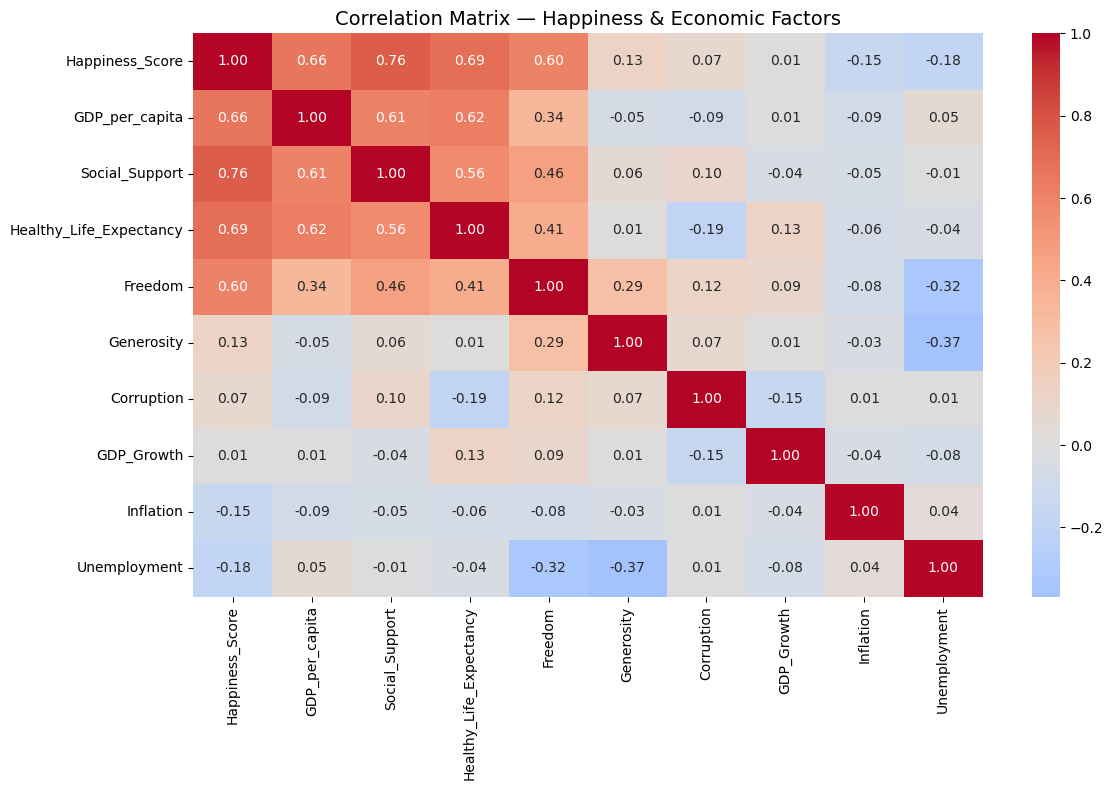

In [7]:
# EDA: Correlation matrix to examine relationships between all variables
numeric_cols = ['Happiness_Score', 'GDP_per_capita', 'Social_Support', 
                'Healthy_Life_Expectancy', 'Freedom', 'Generosity', 
                'Corruption', 'GDP_Growth', 'Inflation', 'Unemployment']

plt.figure(figsize=(12, 8))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Happiness & Economic Factors', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


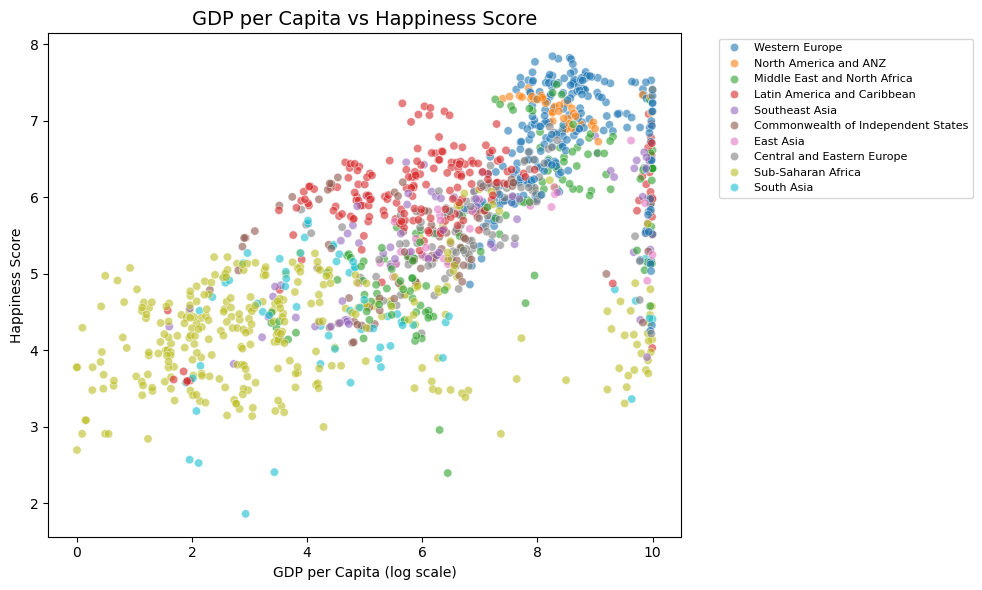

In [8]:
# EDA: Scatter plot of GDP per capita vs happiness score by region
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='GDP_per_capita', y='Happiness_Score', 
                hue='Region', alpha=0.6)
plt.title('GDP per Capita vs Happiness Score', fontsize=14)
plt.xlabel('GDP per Capita (log scale)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('gdp_vs_happiness.png', dpi=150)
plt.show()

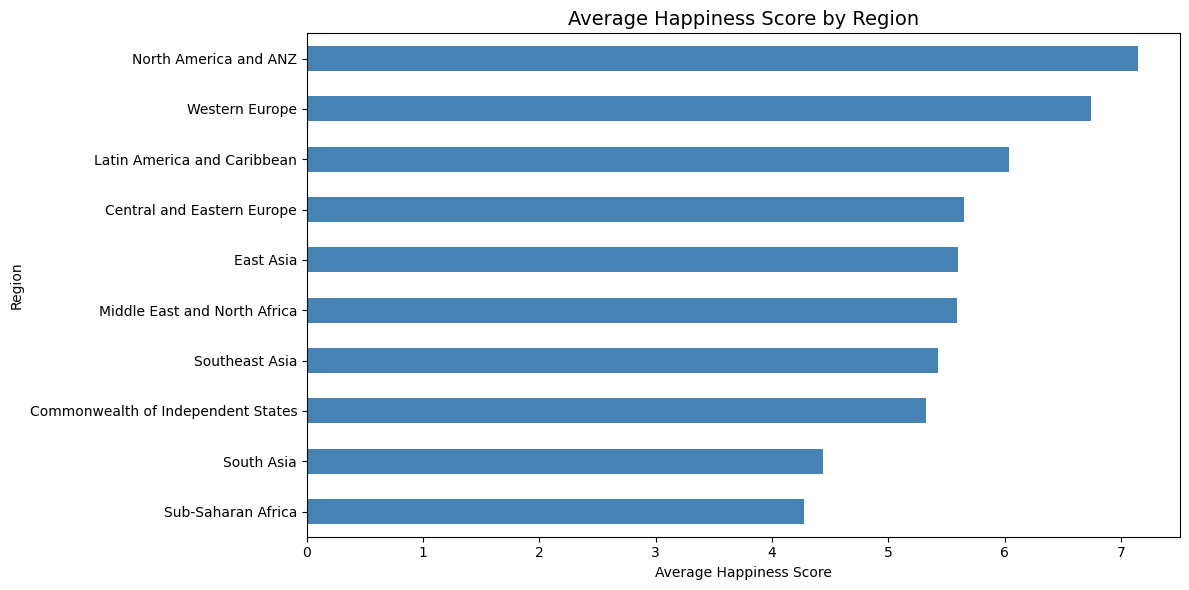

In [9]:
# EDA: Average happiness score by region
plt.figure(figsize=(12, 6))
region_avg = df_clean.groupby('Region')['Happiness_Score'].mean().sort_values(ascending=True)
region_avg.plot(kind='barh', color='steelblue')
plt.title('Average Happiness Score by Region', fontsize=14)
plt.xlabel('Average Happiness Score')
plt.tight_layout()
plt.savefig('region_happiness.png', dpi=150)
plt.show()

In [10]:
from scipy import stats
# Hypothesis testing: Pearson correlation tests for economic variables vs happiness

variables = ['GDP_per_capita', 'GDP_Growth', 'Inflation', 'Unemployment']

for var in variables:
    corr, pvalue = stats.pearsonr(df_clean[var].dropna(), 
                                   df_clean.loc[df_clean[var].notna(), 'Happiness_Score'])
    significance = "Significant" if pvalue < 0.05 else "Not Significant"
    print(f"{var}:")
    print(f"  Correlation: {corr:.3f} | p-value: {pvalue:.4f} | {significance}")
    print()

GDP_per_capita:
  Correlation: 0.657 | p-value: 0.0000 | Significant

GDP_Growth:
  Correlation: 0.012 | p-value: 0.6727 | Not Significant

Inflation:
  Correlation: -0.149 | p-value: 0.0000 | Significant

Unemployment:
  Correlation: -0.180 | p-value: 0.0000 | Significant



In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
# ML modeling: baseline comparison of Linear Regression and Random Forest
features = ['GDP_per_capita', 'GDP_Growth', 'Inflation', 'Unemployment',
            'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity', 'Corruption']

X = df_clean[features].dropna()
y = df_clean.loc[X.index, 'Happiness_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, rf_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Linear Regression R2:", round(lr_r2, 3), "MAE:", round(lr_mae, 3))
print("Random Forest R2:", round(rf_r2, 3), "MAE:", round(rf_mae, 3))

Linear Regression R2: 0.742 MAE: 0.451
Random Forest R2: 0.821 MAE: 0.348


In [12]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, learning_curve)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
# ML modeling: feature setup, train/test split, and feature scaling
warnings.filterwarnings('ignore')

features = ['GDP_per_capita', 'GDP_Growth', 'Inflation', 'Unemployment',
            'Social_Support', 'Healthy_Life_Expectancy', 'Freedom',
            'Generosity', 'Corruption']

X = df_clean[features].dropna()
y = df_clean.loc[X.index, 'Happiness_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Features     : {X_train.shape[1]}")

Training set : 1017 samples
Test set     : 255 samples
Features     : 9


In [14]:
# 5-fold cross-validation comparison of all five models
cv_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge (α=1)'       : Ridge(alpha=1.0),
    'Lasso (α=0.1)'     : Lasso(alpha=0.1),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

cv_results = {}
for name, model in cv_models.items():
    X_cv = X_train_sc if name in ['Ridge (α=1)', 'Lasso (α=0.1)'] else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f"{name:<25} CV R²: {scores.mean():.3f} ± {scores.std():.3f}")

Linear Regression         CV R²: 0.740 ± 0.041
Ridge (α=1)               CV R²: 0.741 ± 0.041
Lasso (α=0.1)             CV R²: 0.730 ± 0.020
Random Forest             CV R²: 0.830 ± 0.020
Gradient Boosting         CV R²: 0.820 ± 0.019


In [15]:
# Test set evaluation: R², MAE, and RMSE for all models
results = []

for name, model in cv_models.items():
    X_tr = X_train_sc if name in ['Ridge (α=1)', 'Lasso (α=0.1)'] else X_train
    X_te = X_test_sc  if name in ['Ridge (α=1)', 'Lasso (α=0.1)'] else X_test
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    results.append({
        'Model' : name,
        'R²'    : round(r2_score(y_test, preds), 3),
        'MAE'   : round(mean_absolute_error(y_test, preds), 3),
        'RMSE'  : round(mean_squared_error(y_test, preds)**0.5, 3),
        'CV R²' : round(cv_results[name].mean(), 3),
    })

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(results_df.to_string(index=False))

            Model    R²   MAE  RMSE  CV R²
    Random Forest 0.821 0.348 0.476  0.830
Gradient Boosting 0.820 0.357 0.477  0.820
Linear Regression 0.742 0.451 0.571  0.740
      Ridge (α=1) 0.742 0.451 0.571  0.741
    Lasso (α=0.1) 0.694 0.491 0.622  0.730


In [18]:
# Hyperparameter tuning: GridSearchCV for Gradient Boosting
param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 4, 5],
    'learning_rate' : [0.05, 0.1, 0.2],
}

gb_base = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(
    gb_base, param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

best_gb = grid_search.best_estimator_
best_preds = best_gb.predict(X_test)

print("Best params  :", grid_search.best_params_)
print(f"Best CV R²   : {grid_search.best_score_:.3f}")
print(f"Test R²      : {r2_score(y_test, best_preds):.3f}")
print(f"Test MAE     : {mean_absolute_error(y_test, best_preds):.3f}")

Best params  : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV R²   : 0.832
Test R²      : 0.823
Test MAE     : 0.353


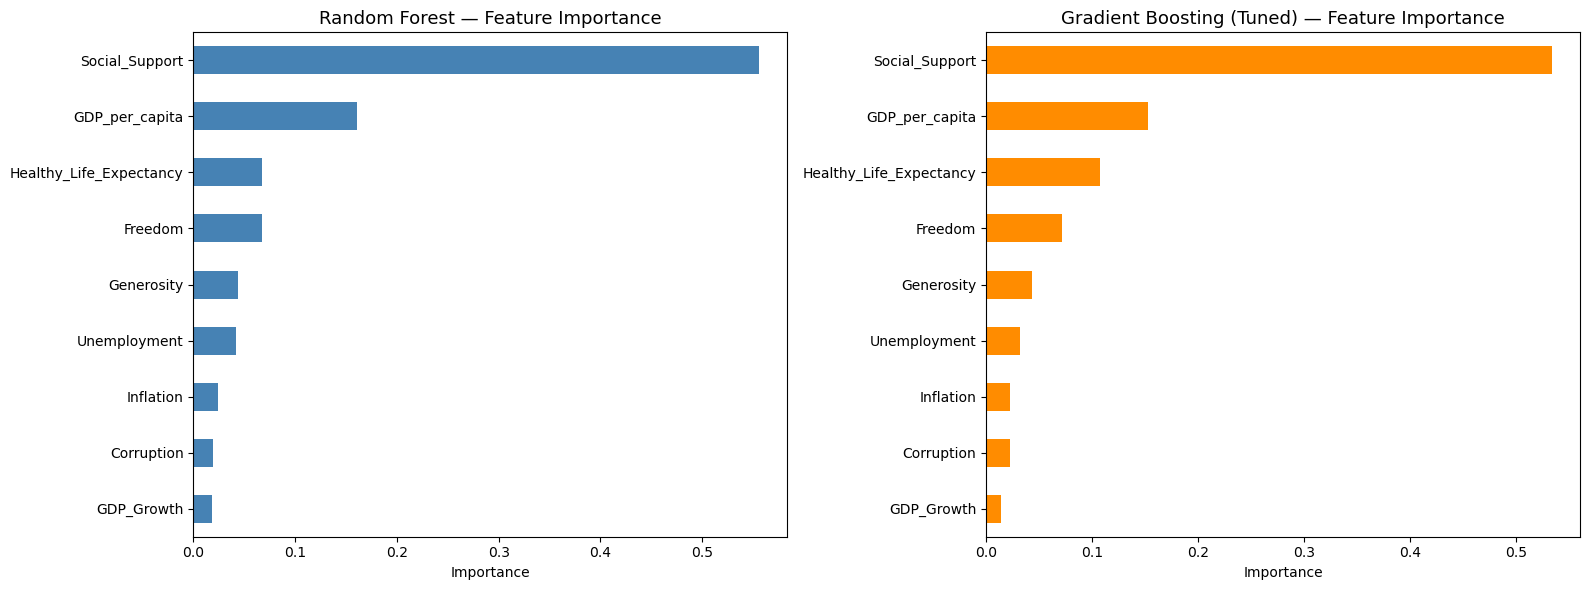

In [19]:
# Feature importance comparison: Random Forest vs Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


rf_model = cv_models['Random Forest']
rf_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values()
rf_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest — Feature Importance', fontsize=13)
axes[0].set_xlabel('Importance')

gb_imp = pd.Series(best_gb.feature_importances_, index=features).sort_values()
gb_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Gradient Boosting (Tuned) — Feature Importance', fontsize=13)
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

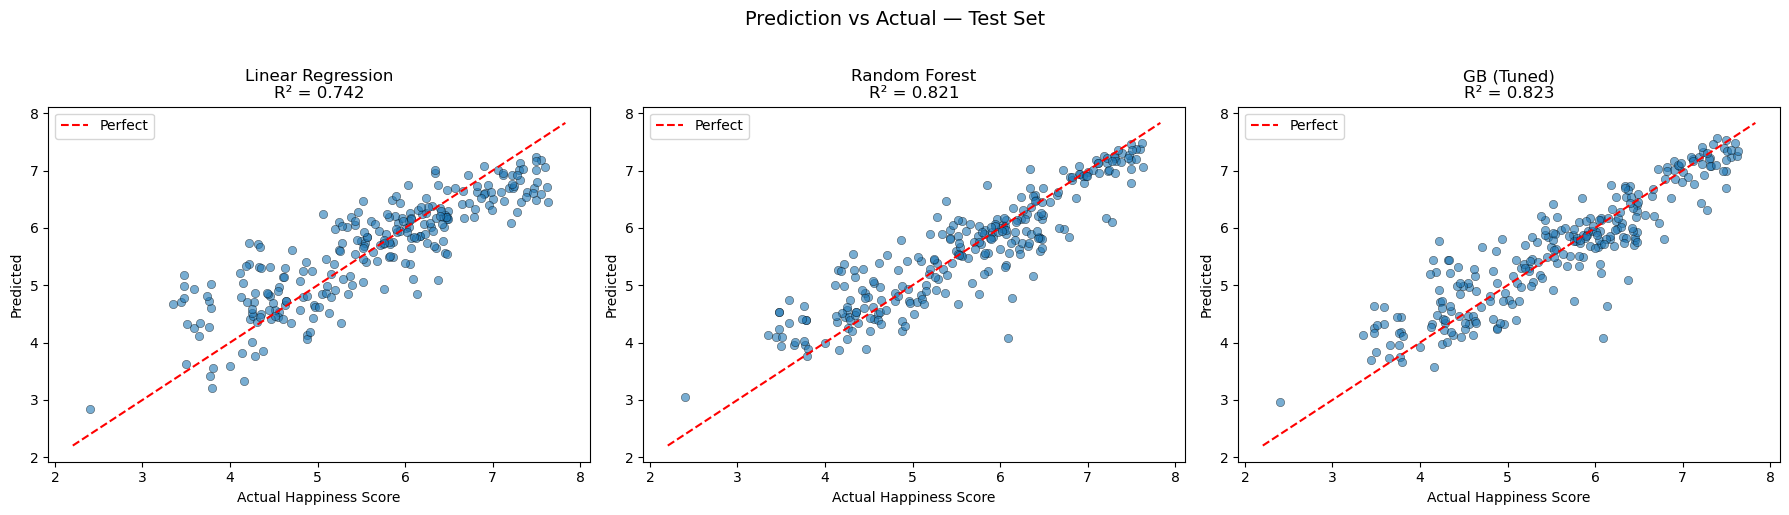

In [20]:
# Prediction vs actual plots for Linear Regression, Random Forest, and Gradient Boosting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_models = [
    ('Linear Regression', cv_models['Linear Regression'], X_test),
    ('Random Forest',     cv_models['Random Forest'],     X_test),
    ('GB (Tuned)',        best_gb,                        X_test),
]

for ax, (name, model, Xte) in zip(axes, plot_models):
    preds = model.predict(Xte)
    r2 = r2_score(y_test, preds)
    ax.scatter(y_test, preds, alpha=0.6, edgecolors='k', linewidths=0.4)
    lims = [min(y_test.min(), preds.min()) - 0.2,
            max(y_test.max(), preds.max()) + 0.2]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
    ax.set_title(f"{name}\nR² = {r2:.3f}", fontsize=12)
    ax.set_xlabel('Actual Happiness Score')
    ax.set_ylabel('Predicted')
    ax.legend()

plt.suptitle('Prediction vs Actual — Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150)
plt.show()

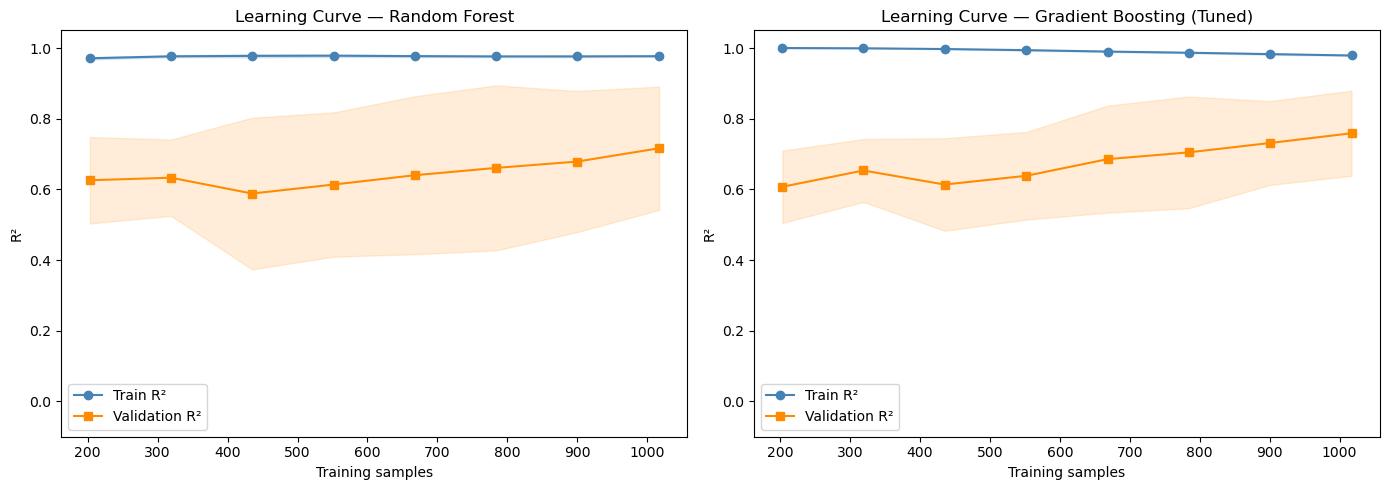

In [21]:
# Learning curves to check for overfitting before regularization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lc_models = [
    ('Random Forest',        cv_models['Random Forest']),
    ('Gradient Boosting (Tuned)', best_gb),
]

train_sizes = np.linspace(0.2, 1.0, 8)

for ax, (name, model) in zip(axes, lc_models):
    sizes, train_sc, val_sc = learning_curve(
        model, X, y,
        train_sizes=train_sizes,
        cv=5, scoring='r2', n_jobs=-1
    )
    ax.plot(sizes, train_sc.mean(axis=1), 'o-', label='Train R²',      color='steelblue')
    ax.plot(sizes, val_sc.mean(axis=1),   's-', label='Validation R²', color='darkorange')
    ax.fill_between(sizes,
        train_sc.mean(1) - train_sc.std(1),
        train_sc.mean(1) + train_sc.std(1), alpha=0.15, color='steelblue')
    ax.fill_between(sizes,
        val_sc.mean(1) - val_sc.std(1),
        val_sc.mean(1) + val_sc.std(1),   alpha=0.15, color='darkorange')
    ax.set_title(f'Learning Curve — {name}', fontsize=12)
    ax.set_xlabel('Training samples')
    ax.set_ylabel('R²')
    ax.legend()
    ax.set_ylim([-0.1, 1.05])

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

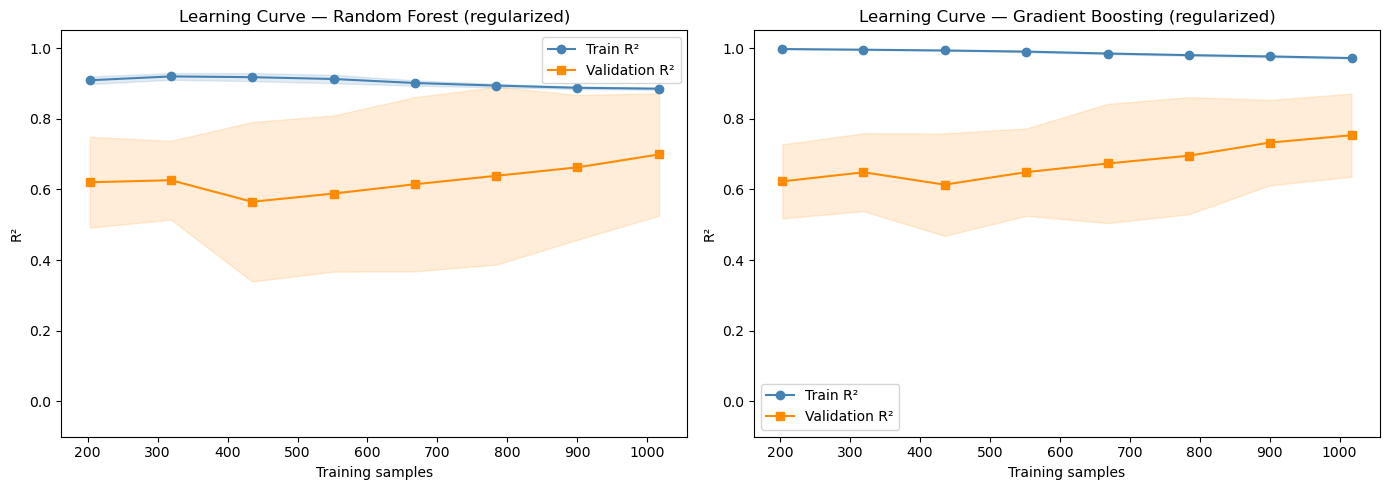

Random Forest (regularized): R²=0.796, MAE=0.377
Gradient Boosting (regularized): R²=0.841, MAE=0.327


In [22]:
# Regularized models: learning curves after applying constraints to reduce overfitting
rf_reg = RandomForestRegressor(
    n_estimators=100, max_depth=6,
    min_samples_leaf=5, random_state=42
)
gb_reg = GradientBoostingRegressor(
    n_estimators=200, max_depth=4,
    learning_rate=0.1, min_samples_leaf=10,
    subsample=0.8, random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lc_models = [('Random Forest (regularized)', rf_reg),
             ('Gradient Boosting (regularized)', gb_reg)]

for ax, (name, model) in zip(axes, lc_models):
    sizes, train_sc, val_sc = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.2, 1.0, 8),
        cv=5, scoring='r2', n_jobs=-1
    )
    ax.plot(sizes, train_sc.mean(axis=1), 'o-', label='Train R²',      color='steelblue')
    ax.plot(sizes, val_sc.mean(axis=1),   's-', label='Validation R²', color='darkorange')
    ax.fill_between(sizes,
        train_sc.mean(1)-train_sc.std(1),
        train_sc.mean(1)+train_sc.std(1), alpha=0.15, color='steelblue')
    ax.fill_between(sizes,
        val_sc.mean(1)-val_sc.std(1),
        val_sc.mean(1)+val_sc.std(1), alpha=0.15, color='darkorange')
    ax.set_title(f'Learning Curve — {name}', fontsize=12)
    ax.set_xlabel('Training samples')
    ax.set_ylabel('R²')
    ax.legend()
    ax.set_ylim([-0.1, 1.05])

plt.tight_layout()
plt.savefig('learning_curves_regularized.png', dpi=150)
plt.show()


for name, model in lc_models:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{name}: R²={r2_score(y_test, preds):.3f}, MAE={mean_absolute_error(y_test, preds):.3f}")

In [23]:
# Lasso feature selection: identify which features survive regularization
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_train_sc, y_train)


lasso_coef = pd.Series(lasso_cv.coef_, index=features)
print("Optimal alpha:", lasso_cv.alpha_)
print("\nLasso Coefficients:")
print(lasso_coef.sort_values())
print("\nFeatures eliminated (coef=0):")
print(lasso_coef[lasso_coef == 0].index.tolist())
print("\nFeatures kept:")
print(lasso_coef[lasso_coef != 0].index.tolist())

Optimal alpha: 0.02698384920218468

Lasso Coefficients:
Unemployment              -0.084715
Inflation                 -0.075307
GDP_Growth                -0.000000
Generosity                -0.000000
Corruption                 0.056035
Freedom                    0.216411
GDP_per_capita             0.218924
Healthy_Life_Expectancy    0.285134
Social_Support             0.450322
dtype: float64

Features eliminated (coef=0):
['GDP_Growth', 'Generosity']

Features kept:
['GDP_per_capita', 'Inflation', 'Unemployment', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Corruption']
